In [26]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time

In [27]:
# パラメーター
compare_month = 5

In [28]:
def load_and_filter_data(file_path):
    df = pd.read_csv(file_path)
    
    # check if ticker_code is a 4-digit number
    def is_four_digit_number(x):
        if isinstance(x, str):
            return x.isdigit() and len(x) == 4
        return False
    
    # filter data
    df_filtered = df[df['TICKER_CODE'].apply(is_four_digit_number)]
    
    # check the result
    print("original data:", len(df))
    print("filtered data:", len(df_filtered))
    
    return df_filtered

# load and filter data
df_filtered = load_and_filter_data('../data/668f9d46-ba94-4582-8496-d5ac9a7d2ce2.csv')
df_filtered

original data: 1107800
filtered data: 1012797


,DATE,COUNT,TOTAL_SALES,TICKER_CODE
0,2013-01-01,20,73761,2138
1,2013-01-01,12,85905,2157
2,2013-01-01,2,4070,2193
3,2013-01-01,35,120393,2211
4,2013-01-01,2,6000,2267
...,...,...,...,...
1107795,2026-03-31,3364,11895353,4478
1107796,2026-04-30,1724,5072281,3994
1107797,2026-04-30,1695,5980035,4478
1107798,2026-05-31,39,149150,3994


In [29]:
def calculate_monthly_growth(df_filtered):
    # convert DATE to datetime
    df_filtered['DATE'] = pd.to_datetime(df_filtered['DATE'])

    # filter data from April 2021
    end_date = pd.to_datetime('2025-07-01')
    df_filtered = df_filtered[df_filtered['DATE'] <= end_date]
    
    # add 'year-month' column for monthly aggregation
    df_filtered['year-month'] = df_filtered['DATE'].dt.to_period('M')
    
    # sum by TICKER_CODE and year-month
    monthly_total = df_filtered.groupby(['year-month', 'TICKER_CODE'])['TOTAL_SALES'].sum().reset_index()
    monthly_total.rename(columns={'year-month': 'DATE'}, inplace=True)
    
    # calculate growth rate
    monthly_total['prev_month_sales'] = monthly_total.groupby('TICKER_CODE')['TOTAL_SALES'].shift(1)
    monthly_total['growth_rate'] = (monthly_total['TOTAL_SALES'] - monthly_total['prev_month_sales']) / monthly_total['prev_month_sales']
    monthly_total = monthly_total.dropna(subset=['growth_rate'])

    # growth rateのYoY
    monthly_total['prev_year_growth_rate'] = monthly_total.groupby('TICKER_CODE')['growth_rate'].shift(12)
    monthly_total['YoY'] = monthly_total['growth_rate'] - monthly_total['prev_year_growth_rate']
    monthly_total = monthly_total.dropna(subset=['YoY'])
    
    # exclude the latest month
    latest_month = monthly_total['DATE'].max()
    monthly_total = monthly_total[monthly_total['DATE'] != latest_month]
    
    # convert DATE to string
    monthly_total['DATE'] = monthly_total['DATE'].astype(str)
    
    return monthly_total



# calculate monthly growth rate
monthly_total = calculate_monthly_growth(df_filtered)

# 不要なカラムの削除
monthly_total = monthly_total.drop(columns=['TOTAL_SALES', 'prev_month_sales', 'growth_rate', 'prev_year_growth_rate'])

# order by TICKER_CODE AND DATE
monthly_total = monthly_total.sort_values(by=['TICKER_CODE', 'DATE'])

monthly_total

C:\Users\hh080\AppData\Local\Temp\ipykernel_20120\527799334.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year-month'] = df_filtered['DATE'].dt.to_period('M')


,DATE,TICKER_CODE,YoY
2904,2014-02,2138,-0.459727
3134,2014-03,2138,-0.330166
3363,2014-04,2138,0.525741
3593,2014-05,2138,-0.209207
3822,2014-06,2138,-0.142646
...,...,...,...
33984,2025-01,9997,-0.128289
34222,2025-02,9997,0.129865
34460,2025-03,9997,0.198623
34698,2025-04,9997,-0.287542


In [30]:
# 過去3ヶ月の平均との比較
monthly_total['prev_n_months_avg'] = monthly_total.groupby('TICKER_CODE')['YoY'].rolling(window=compare_month).mean().reset_index(0, drop=True)
monthly_total['compare_to_n_months_avg'] = monthly_total['YoY'] - monthly_total['prev_n_months_avg']

# nanの削除
yoy_data = monthly_total.dropna(subset=['compare_to_n_months_avg'])

# 不要なカラムの削除
yoy_data = yoy_data.drop(columns=['YoY', 'prev_n_months_avg'])

yoy_data

,DATE,TICKER_CODE,compare_to_n_months_avg
3822,2014-06,2138,-0.019445
4052,2014-07,2138,0.001649
4283,2014-08,2138,-0.052582
4514,2014-09,2138,0.452519
4745,2014-10,2138,-0.012651
...,...,...,...
33984,2025-01,9997,-0.130458
34222,2025-02,9997,0.103975
34460,2025-03,9997,0.118539
34698,2025-04,9997,-0.279378


In [31]:
quantile_data = []

# YoY, compare_to_n_months_avgを用いたquantileの作成
for date in yoy_data['DATE'].unique():
    date_data = yoy_data[yoy_data['DATE'] == date].copy()  # .copy()を追加

    date_data.loc[:, 'quantile_YoY_compare_to_n_months_avg'] = pd.qcut(date_data['compare_to_n_months_avg'], 4, labels=range(1, 4 + 1))

    quantile_data.append(date_data)

quantile_df = pd.concat(quantile_data)

quantile_df.dropna(inplace=True)

# quantile_df = quantile_df.drop(columns=['compare_to_n_months_avg'])

quantile_df

,DATE,TICKER_CODE,compare_to_n_months_avg,quantile_YoY_compare_to_n_months_avg
3822,2014-06,2138,-0.019445,3
3823,2014-06,2157,0.046862,4
3824,2014-06,2193,-0.004545,3
3825,2014-06,2211,-0.193115,1
3826,2014-06,2267,-1.122738,1
...,...,...,...,...
34932,2025-05,9974,0.013808,3
34933,2025-05,9983,0.146780,4
34934,2025-05,9984,-0.235704,1
34935,2025-05,9989,-0.057453,2


In [32]:
# create portfolio weights by quantile

def create_portfolio_weights(quantile_df):
    portfolio_weights = []
    for date in quantile_df['DATE'].unique():
        date_quantiles = quantile_df[quantile_df['DATE'] == date]
        for quantile in range(1, 4 + 1):
            quantile_stocks = date_quantiles[date_quantiles['quantile_YoY_compare_to_n_months_avg'] == quantile]
            if not quantile_stocks.empty:
                weight = 1.0 / len(quantile_stocks)
                for _, row in quantile_stocks.iterrows():
                    portfolio_weights.append({'DATE': date, 'TICKER_CODE': row['TICKER_CODE'], f'quantile_{quantile}': weight})
        
        portfolio_weights_df = pd.DataFrame(portfolio_weights)
        portfolio_weights_df = portfolio_weights_df.fillna(0)

    return portfolio_weights_df

portfolio_weights_df = create_portfolio_weights(quantile_df)

portfolio_weights_df

,DATE,TICKER_CODE,quantile_1,quantile_2,quantile_3,quantile_4
0,2014-06,2211,0.018182,0.0,0.0,0.000000
1,2014-06,2267,0.018182,0.0,0.0,0.000000
2,2014-06,2651,0.018182,0.0,0.0,0.000000
3,2014-06,2670,0.018182,0.0,0.0,0.000000
4,2014-06,2695,0.018182,0.0,0.0,0.000000
...,...,...,...,...,...,...
30869,2025-05,9766,0.000000,0.0,0.0,0.016667
30870,2025-05,9861,0.000000,0.0,0.0,0.016667
30871,2025-05,9900,0.000000,0.0,0.0,0.016667
30872,2025-05,9983,0.000000,0.0,0.0,0.016667


In [33]:
# # save portfolio weights
# portfolio_weights_df.to_csv('../data/output/portfolio_weights.csv', index=False)

In [34]:
# load price data
price_data = pd.read_csv('../data/new_price_data.csv')

price_data = price_data.drop(columns=['dividends'])

price_data = price_data[price_data['DATE'] <= '2025-05-01']
price_data = price_data[price_data['DATE'] >= '2014-03-01']

price_data

,DATE,TICKER_CODE,price,monthly_return
15,2014-04,2138,4040.090820,-0.108398
16,2014-05,2138,4222.166016,0.045067
17,2014-06,2138,4182.798828,-0.009324
18,2014-07,2138,3710.388184,-0.112941
19,2014-08,2138,3011.614746,-0.188329
...,...,...,...,...
30498,2025-01,5032,3162.055420,0.132813
30499,2025-02,5032,2811.156250,-0.110972
30500,2025-03,5032,3201.704834,0.138928
30501,2025-04,5032,3667.587646,0.155662


In [35]:
# DATEの形式を統一
portfolio_weights_df['DATE'] = pd.to_datetime(portfolio_weights_df['DATE']).dt.strftime('%Y-%m')
price_data['DATE'] = pd.to_datetime(price_data['DATE']).dt.strftime('%Y-%m')

# TICKER_CODEの型を統一（文字列に変換）
portfolio_weights_df['TICKER_CODE'] = portfolio_weights_df['TICKER_CODE'].astype(str)
price_data['TICKER_CODE'] = price_data['TICKER_CODE'].astype(str)

# リターンマトリックスの作成
returns_matrix = price_data.pivot(index='DATE', columns='TICKER_CODE', values='monthly_return')

# 各クォンタイルのリターン計算
portfolio_returns = pd.DataFrame(index=returns_matrix.index)

# クォンタイル列の自動検出
quantile_cols = [col for col in portfolio_weights_df.columns if col.startswith('quantile_')]

for quantile_col in quantile_cols:
    # ウェイトの取得
    weights = portfolio_weights_df.pivot(index='DATE', columns='TICKER_CODE', values=quantile_col)

    # インデックスの整合性確認
    common_dates = weights.index.intersection(returns_matrix.index)

    if len(common_dates) == 0:
        print(f"Warning: No common dates found between weights and returns for {quantile_col}")
        continue

    # リターンの計算
    # 1. 共通の日付でデータを抽出
    weights_common = weights.loc[common_dates]
    returns_common = returns_matrix.loc[common_dates]
    
    # 2. 共通のカラム（銘柄）を取得
    common_columns = weights_common.columns.intersection(returns_common.columns)
    
    if len(common_columns) == 0:
        print("Warning: No common columns found between weights and returns")
        continue
        
    weights_common = weights_common[common_columns]
    returns_common = returns_common[common_columns]
    
    # 3. NaNを0に置換
    weights_common = weights_common.fillna(0)
    returns_common = returns_common.fillna(0)
    
    weighted_returns = weights_common * returns_common
    
    # 5. 合計を計算
    returns = weighted_returns.sum(axis=1)
    
    portfolio_returns[quantile_col] = returns

# NaNを除去
portfolio_returns = portfolio_returns.dropna()

portfolio_returns

,quantile_1,quantile_2,quantile_3,quantile_4
DATE,,,,
2014-06,0.052063,0.046550,0.054642,0.039023
2014-07,0.006156,0.043699,0.022404,0.030927
2014-08,0.014181,0.003917,-0.032199,0.009634
2014-09,0.025782,0.024949,0.010553,0.012707
2014-10,0.066007,0.018571,0.018394,0.011638
...,...,...,...,...
2025-01,0.011394,0.013983,0.011585,0.024582
2025-02,-0.032106,-0.018351,-0.007072,-0.022378
2025-03,0.021185,0.020411,0.025356,0.014042


In [36]:
# save portfolio returns
portfolio_returns.to_csv('../data/output/portfolio_returns1325.csv')

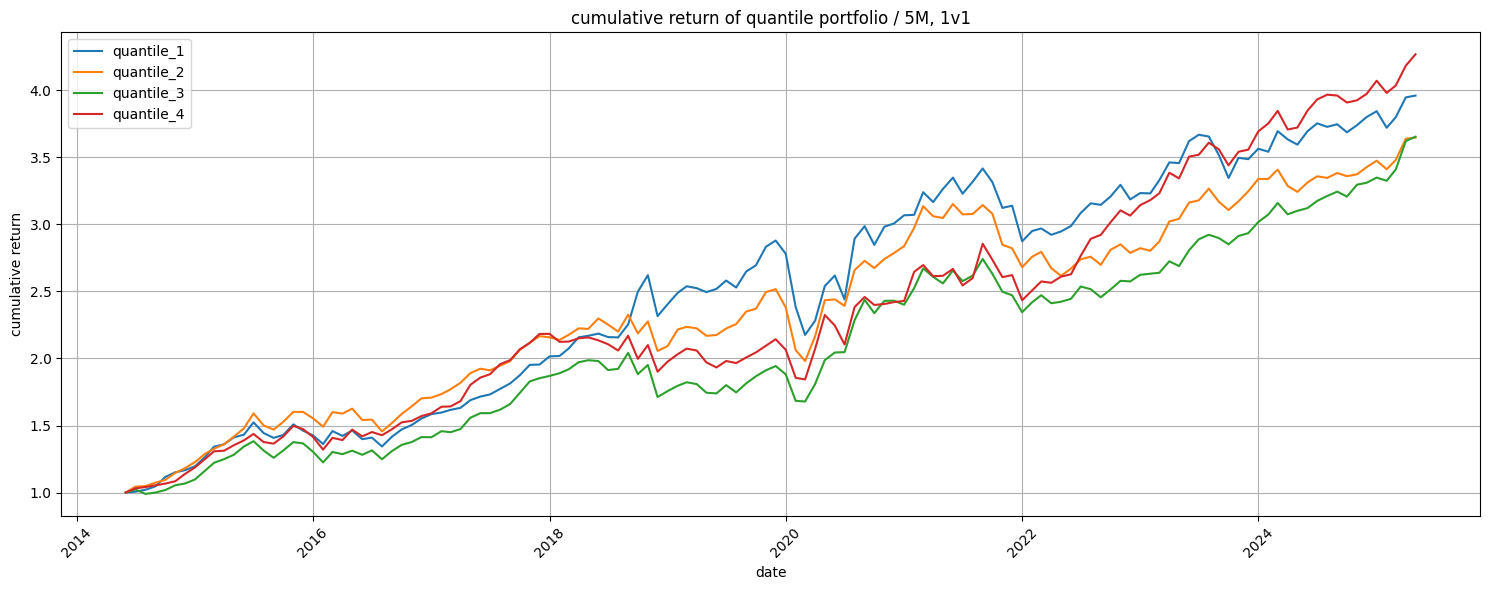

In [37]:
def plot_portfolio_returns(portfolio_returns):
    plt.figure(figsize=(15, 6))
    for col in portfolio_returns.columns:

        # 累計リターンを計算
        cumulative_returns = (1 + portfolio_returns[col]).cumprod()
        
        # 初月が1になるように調整
        cumulative_returns = cumulative_returns / cumulative_returns.iloc[0]

        plt.plot(portfolio_returns.index, 
        cumulative_returns, 
        label=col)

    plt.title(f'cumulative return of quantile portfolio / {compare_month}M, 1v1')
    plt.xlabel('date')
    plt.ylabel('cumulative return')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f'../data/output/{compare_month}M.png')


# set date index
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)

# visualize growth rate
plot_portfolio_returns(portfolio_returns)